In [ ]:
!pip install git+https://github.com/ClementPla/fundus-odmac-toolkit.git

^C


In [ ]:
!pip install fundus-data-toolkit

  Cloning https://github.com/ClementPla/NNTools (to revision attrs_dataset) to C:\Users\DARSHAN\AppData\Local\Temp\pip-install-8hk79m9_\nntools_a60a8f41760844938ebff4575578087b
  Resolved https://github.com/ClementPla/NNTools to commit 9ca4c48de01891a9af756a5e3b3d74c650e1cbfc
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/ClementPla/NNTools 'C:\Users\DARSHAN\AppData\Local\Temp\pip-install-8hk79m9_\nntools_a60a8f41760844938ebff4575578087b'
  Running command git checkout -b attrs_dataset --track origin/attrs_dataset
  branch 'attrs_dataset' set up to track 'origin/attrs_dataset'.
  Switched to a new branch 'attrs_dataset'


In [ ]:
from fundus_data_toolkit.functional import open_image
from fundus_odmac_toolkit.models.segmentation import segment

image_path = r"D:\Projects\College\Rabcl\BRSET_processed\train\197\right.jpg"

image = open_image(image_path)

pred = segment(
    image,
    arch="unet",
    encoder="maxvit_small_tf_512"
)

print(pred.shape)

torch.Size([3, 384, 384])


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from fundus_odmac_toolkit.models.segmentation import segment


image_path = r"D:\Projects\College\Rabcl\BRSET_processed\train\197\left.jpg"


# ------------------------------------------------------------
# Load as 3-channel BGR
# ------------------------------------------------------------

image_bgr = cv2.imread(
    image_path,
    cv2.IMREAD_COLOR
)

if image_bgr is None:
    raise FileNotFoundError(
        f"Could not read: {image_path}"
    )


# ------------------------------------------------------------
# BGR → RGB
# ------------------------------------------------------------

image = cv2.cvtColor(
    image_bgr,
    cv2.COLOR_BGR2RGB
)


print("Image shape:", image.shape)
print("Image dtype:", image.dtype)


# ------------------------------------------------------------
# Pretrained U-Net + MaxViT
# ------------------------------------------------------------

pred = segment(
    image,
    arch="unet",
    encoder="maxvit_small_tf_512"
)


print("Prediction shape:", pred.shape)

Image shape: (384, 384, 3)
Image dtype: uint8
Prediction shape: torch.Size([3, 384, 384])


In [ ]:
from fundus_data_toolkit.functional import open_image
from fundus_odmac_toolkit.models.segmentation import segment

image_path = r"D:\Projects\College\Rabcl\BRSET_processed\train\197\left.jpg"

image = open_image(image_path)

print("type:", type(image))
print("shape:", image.shape)
print("dtype:", image.dtype)
print("ndim:", image.ndim)

pred = segment(
    image,
    arch="unet",
    encoder="maxvit_small_tf_512"
)

type: <class 'numpy.ndarray'>
shape: (384, 384, 3)
dtype: uint8
ndim: 3


In [71]:
import inspect
from fundus_data_toolkit.functional import autofit_fundus_resolution

print(inspect.getsource(autofit_fundus_resolution))

def autofit_fundus_resolution(fundus, max_size, return_roi=False):
    """
    This function does all the necessary operations to fit a fundus image into a square shape, including automatic removal of black borders
    It returns the parameters to be given to the reverse_autofit() function to inverse the transformation
    Args:
        fundus (np.ndarray): _description_
        max_size (int): _description_
        return_roi (bool)
    """
    image, roi, margins = autocrop_fundus(fundus)
    h, w = image.shape[:2]
    f = max_size / max((h, w))
    image = cv2.resize(image, fx=f, fy=f, dsize=None, interpolation=cv2.INTER_CUBIC)
    h, w = image.shape[:2]
    padh = (max_size - h) // 2, (max_size - h) // 2 + ((max_size - h) % 2)
    padw = (max_size - w) // 2, (max_size - w) // 2 + ((max_size - w) % 2)

    reverse_params = {
        "pad": margins,
        "resize": 1.0 / f,
        "crop": (padh[0], padh[0] + h, padw[0], padw[0] + w),
    }
    padded_image = np.pad(image, (padh, p

In [72]:
import inspect
from fundus_data_toolkit.functional import autocrop_fundus

print(inspect.getsource(autocrop_fundus))

def autocrop_fundus(fundus):
    """
    Removes the black border surrounding a fundus image.

    Args:
        fundus (np.ndarray): Image with HxWxC (RGB)

    Returns:
        Cropped fundus,
        ROI,
        Margins (top, bottom, left, right)
    """

    h, w, c = fundus.shape

    # --------------------------------------------------------
    # Find non-black region
    # --------------------------------------------------------

    max_img = np.max(
        fundus,
        axis=2
    )

    max_value = max_img.max()

    threshold = 0.05 * max_value

    _, roi = cv2.threshold(
        max_img,
        threshold,
        1,
        cv2.THRESH_BINARY
    )

    # --------------------------------------------------------
    # Get coordinates directly
    # --------------------------------------------------------

    ys, xs = np.where(
        roi > 0
    )

    if len(xs) == 0:

        # No foreground detected
        return (
            fundus,
            roi,
           

In [73]:
def autocrop_fundus(fundus):
    """
    Removes the black border surrounding a fundus image.

    Args:
        fundus (np.ndarray): Image with HxWxC (RGB)

    Returns:
        Cropped fundus,
        ROI,
        Margins (top, bottom, left, right)
    """

    h, w, c = fundus.shape

    # --------------------------------------------------------
    # Find non-black region
    # --------------------------------------------------------

    max_img = np.max(
        fundus,
        axis=2
    )

    max_value = max_img.max()

    threshold = 0.05 * max_value

    _, roi = cv2.threshold(
        max_img,
        threshold,
        1,
        cv2.THRESH_BINARY
    )

    # --------------------------------------------------------
    # Get coordinates directly
    # --------------------------------------------------------

    ys, xs = np.where(
        roi > 0
    )

    if len(xs) == 0:

        # No foreground detected
        return (
            fundus,
            roi,
            (0, 0, 0, 0)
        )

    # --------------------------------------------------------
    # Bounding box
    # --------------------------------------------------------

    x_min = xs.min()
    x_max = xs.max()

    y_min = ys.min()
    y_max = ys.max()

    # --------------------------------------------------------
    # Crop
    # --------------------------------------------------------

    fundus_cropped = fundus[
        y_min:y_max + 1,
        x_min:x_max + 1
    ]

    roi_cropped = roi[
        y_min:y_max + 1,
        x_min:x_max + 1
    ]

    # --------------------------------------------------------
    # Margins removed
    # --------------------------------------------------------

    margins_removed = (
        y_min,
        h - (y_max + 1),
        x_min,
        w - (x_max + 1)
    )

    return (
        fundus_cropped,
        roi_cropped,
        margins_removed
    )

In [74]:
import fundus_data_toolkit.functional as fdt

fdt.autocrop_fundus = autocrop_fundus

In [75]:
pred = segment(
    image,
    arch="unet",
    encoder="maxvit_small_tf_512"
)

print("Prediction type:", type(pred))
print("Prediction shape:", pred.shape)

Prediction type: <class 'torch.Tensor'>
Prediction shape: torch.Size([3, 384, 384])


In [76]:
print(pred.shape)

torch.Size([3, 384, 384])


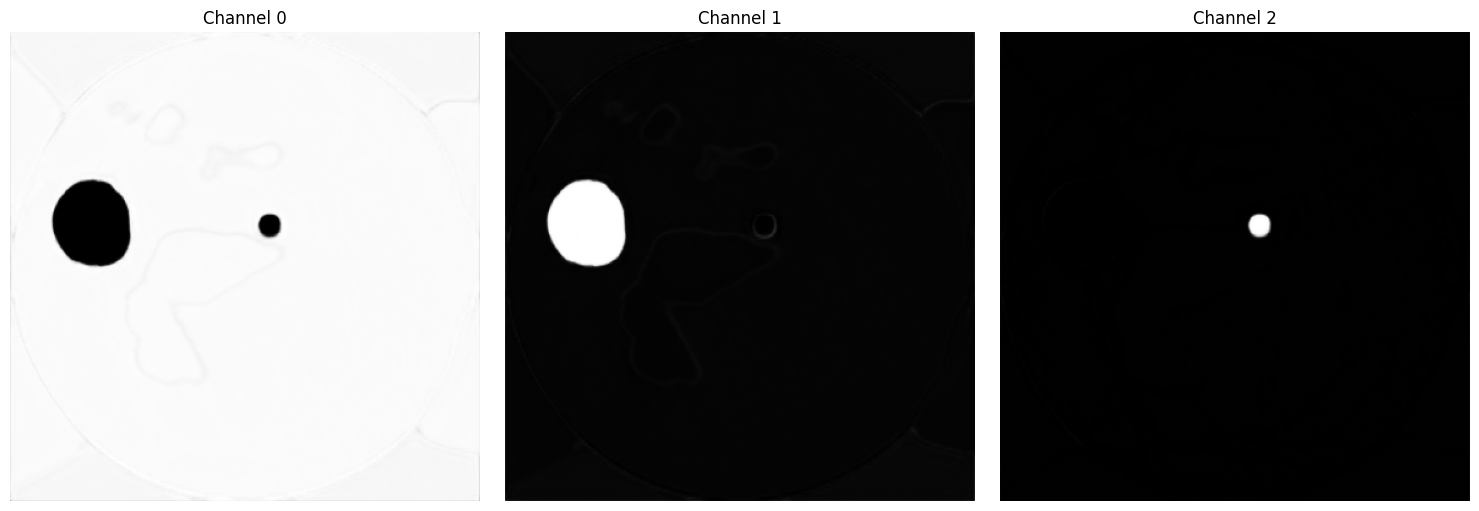

In [77]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 5))

for i in range(3):
    plt.subplot(1, 3, i + 1)

    plt.imshow(
        pred[i].detach().cpu().numpy(),
        cmap="gray"
    )

    plt.title(f"Channel {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [78]:
for i in range(3):
    channel = pred[i].detach().cpu().numpy()

    print(
        f"Channel {i}:",
        "min =", channel.min(),
        "max =", channel.max(),
        "mean =", channel.mean()
    )

Channel 0: min = 6.438592e-05 max = 0.995376 mean = 0.9481091
Channel 1: min = 0.00082965055 max = 0.9992981 mean = 0.04548031
Channel 2: min = 0.0001515242 max = 0.9991048 mean = 0.006410704


In [79]:
macula_probability = (
    pred[2]
    .detach()
    .cpu()
    .numpy()
)

macula_mask = (
    macula_probability >= 0.05
).astype(np.uint8) * 255

print(
    "Macula pixels:",
    np.sum(macula_mask > 0)
)

Macula pixels: 350


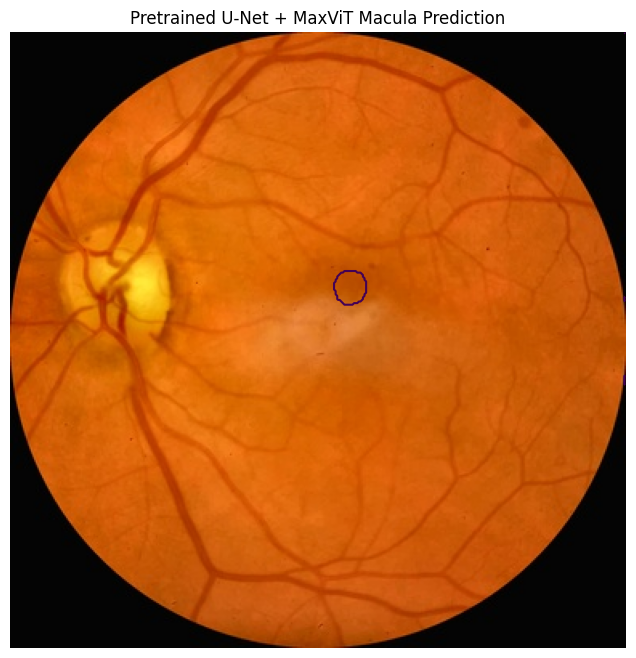

In [80]:
plt.figure(figsize=(8, 8))

plt.imshow(image)

plt.contour(
    macula_mask > 0,
    levels=[0.5]
)

plt.title(
    "Pretrained U-Net + MaxViT Macula Prediction"
)

plt.axis("off")

plt.show()

In [81]:
import cv2
import numpy as np

# Get coordinates of predicted macula
ys, xs = np.where(macula_mask > 0)

if len(xs) == 0:
    raise ValueError("Empty macula prediction")

# Predicted macula center
center_x = int(np.mean(xs))
center_y = int(np.mean(ys))

# Current equivalent radius
current_radius = np.sqrt(
    len(xs) / np.pi
)

# Increase slightly
new_radius = int(
    current_radius * 1.25
)

# Create new ROI
macula_roi = np.zeros_like(
    macula_mask,
    dtype=np.uint8
)

cv2.circle(
    macula_roi,
    (center_x, center_y),
    new_radius,
    255,
    -1
)

print("Center:", center_x, center_y)
print("Original equivalent radius:", current_radius)
print("New radius:", new_radius)
print("ROI pixels:", np.sum(macula_roi > 0))

Center: 216 159
Original equivalent radius: 10.55502061411188
New radius: 13
ROI pixels: 529


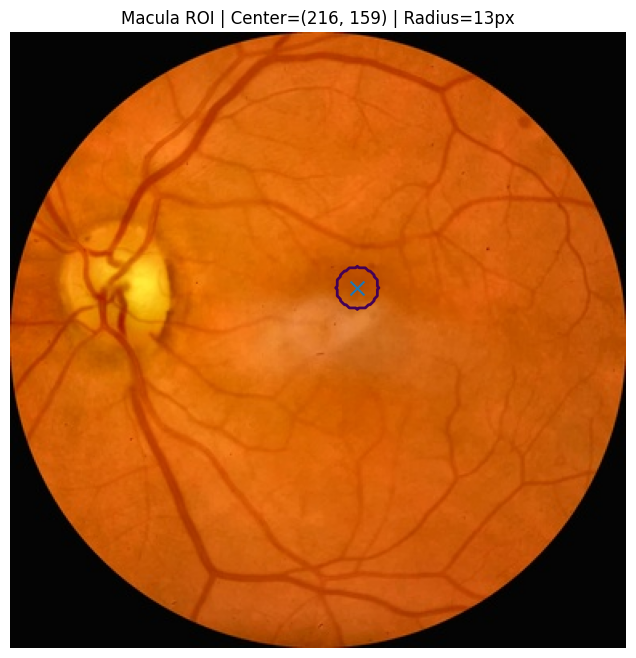

In [82]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

# Original fundus image
plt.imshow(image)

# Show macula ROI boundary
plt.contour(
    macula_roi > 0,
    levels=[0.5],
    linewidths=2
)

# Show predicted macula center
plt.scatter(
    center_x,
    center_y,
    marker="x",
    s=100
)

plt.title(
    f"Macula ROI | Center=({center_x}, {center_y}) | "
    f"Radius={new_radius}px"
)

plt.axis("off")
plt.show()

In [ ]:
# ============================================================
# GENERATE MACULA ROI MASKS FOR ALL BRSET IMAGES
# ============================================================
#
# Input:
#   BRSET_processed/train/{patient_id}/left.jpg
#   BRSET_processed/train/{patient_id}/right.jpg
#
# Output:
#   masks_output/
#   ├── 1/
#   │   ├── Left_macula.png
#   │   └── Right_macula.png
#   ├── 2/
#   │   ├── Left_macula.png
#   │   └── Right_macula.png
#   └── ...
#
# Macula:
#   255 = macula ROI
#     0 = background
#
# ROI:
#   Predicted macula center
#   + 1.25 × predicted equivalent radius
#
# ============================================================

import os
import cv2
import numpy as np
import pandas as pd
import torch
from tqdm.auto import tqdm

from fundus_data_toolkit.functional import open_image
from fundus_odmac_toolkit.models.segmentation import segment
import fundus_data_toolkit.functional as fdt


# ============================================================
# PATHS
# ============================================================

BRSET_DIR = r"D:\Projects\College\Rabcl\BRSET_processed\train"

MANIFEST_PATH = (
    r"D:\Projects\College\Rabcl\preprocessed.csv"
)

MASKS_OUTPUT = (
    r"D:\Projects\College\Rabcl\masks_output"
)

os.makedirs(
    MASKS_OUTPUT,
    exist_ok=True
)


# ============================================================
# IMPORTANT:
# FIX THE autocrop FUNCTION
# ============================================================

def autocrop_fundus(fundus):

    h, w, c = fundus.shape

    max_img = np.max(
        fundus,
        axis=2
    )

    max_value = max_img.max()

    threshold = 0.05 * max_value

    _, roi = cv2.threshold(
        max_img,
        threshold,
        1,
        cv2.THRESH_BINARY
    )

    ys, xs = np.where(
        roi > 0
    )

    if len(xs) == 0:

        return (
            fundus,
            roi,
            (0, 0, 0, 0)
        )

    x_min = xs.min()
    x_max = xs.max()

    y_min = ys.min()
    y_max = ys.max()

    fundus_cropped = fundus[
        y_min:y_max + 1,
        x_min:x_max + 1
    ]

    roi_cropped = roi[
        y_min:y_max + 1,
        x_min:x_max + 1
    ]

    margins_removed = (
        y_min,
        h - (y_max + 1),
        x_min,
        w - (x_max + 1)
    )

    return (
        fundus_cropped,
        roi_cropped,
        margins_removed
    )


# Replace toolkit function with corrected version
fdt.autocrop_fundus = autocrop_fundus


# ============================================================
# LOAD CSV
# ============================================================

manifest = pd.read_csv(
    MANIFEST_PATH
)

print(
    "Total images:",
    len(manifest)
)

print(
    "Total patients:",
    manifest["patient_id"].nunique()
)


# ============================================================
# MACULA ROI FUNCTION
# ============================================================

def generate_macula_roi(image):

    # --------------------------------------------------------
    # Run pretrained U-Net + MaxViT
    # --------------------------------------------------------

    pred = segment(
        image,
        arch="unet",
        encoder="maxvit_small_tf_512"
    )

    # --------------------------------------------------------
    # Channel 2 = macula prediction
    # --------------------------------------------------------

    macula_probability = (
        pred[2]
        .detach()
        .cpu()
        .numpy()
    )

    # --------------------------------------------------------
    # Initial predicted macula mask
    # --------------------------------------------------------

    macula_mask = (
        macula_probability >= 0.5
    ).astype(np.uint8) * 255

    # --------------------------------------------------------
    # Find predicted macula coordinates
    # --------------------------------------------------------

    ys, xs = np.where(
        macula_mask > 0
    )

    if len(xs) == 0:

        return None

    # --------------------------------------------------------
    # Macula center
    # --------------------------------------------------------

    center_x = int(
        np.mean(xs)
    )

    center_y = int(
        np.mean(ys)
    )

    # --------------------------------------------------------
    # Equivalent radius of predicted mask
    #
    # Area = pi*r^2
    # r = sqrt(area/pi)
    # --------------------------------------------------------

    current_radius = np.sqrt(
        len(xs) / np.pi
    )

    # --------------------------------------------------------
    # Increase radius by 1.25×
    # --------------------------------------------------------

    new_radius = int(
        current_radius * 1.25
    )

    # --------------------------------------------------------
    # Create final ROI mask
    # --------------------------------------------------------

    macula_roi = np.zeros_like(
        macula_mask,
        dtype=np.uint8
    )

    cv2.circle(
        macula_roi,
        (
            center_x,
            center_y
        ),
        new_radius,
        255,
        -1
    )

    return macula_roi


# ============================================================
# PROCESS ALL IMAGES
# ============================================================

success = 0
skipped = 0
failed = 0

for _, row in tqdm(
    manifest.iterrows(),
    total=len(manifest),
    desc="Generating macula ROIs"
):

    patient_id = str(
        int(row["patient_id"])
    )

    # --------------------------------------------------------
    # Determine eye
    # --------------------------------------------------------

    eye = str(
        row["exam_eye"]
    ).strip().lower()

    if eye == "left":

        eye_name = "Left"

    elif eye == "right":

        eye_name = "Right"

    else:

        print(
            f"\nUnknown eye: {row['exam_eye']}"
        )

        failed += 1
        continue

    # --------------------------------------------------------
    # Patient folder
    # --------------------------------------------------------

    patient_folder = os.path.join(
        MASKS_OUTPUT,
        patient_id
    )

    os.makedirs(
        patient_folder,
        exist_ok=True
    )

    # --------------------------------------------------------
    # Input image
    # --------------------------------------------------------

    image_path = os.path.join(
        BRSET_DIR,
        patient_id,
        eye + ".jpg"
    )

    # --------------------------------------------------------
    # Output mask
    # --------------------------------------------------------

    output_path = os.path.join(
        patient_folder,
        f"{eye_name}_macula.png"
    )

    # --------------------------------------------------------
    # Skip if already generated
    # --------------------------------------------------------

    if os.path.isfile(output_path):

        skipped += 1
        continue

    try:

        # ----------------------------------------------------
        # Load image
        # ----------------------------------------------------

        image = open_image(
            image_path
        )

        # ----------------------------------------------------
        # Verify input
        # ----------------------------------------------------

        if image.ndim != 3:

            raise ValueError(
                f"Expected RGB image, got shape {image.shape}"
            )

        # ----------------------------------------------------
        # Generate macula ROI
        # ----------------------------------------------------

        macula_roi = generate_macula_roi(
            image
        )

        if macula_roi is None:

            print(
                f"\nEmpty macula prediction: "
                f"patient {patient_id}, {eye}"
            )

            failed += 1
            continue

        # ----------------------------------------------------
        # Save mask
        # ----------------------------------------------------

        success_write = cv2.imwrite(
            output_path,
            macula_roi
        )

        if not success_write:

            raise IOError(
                f"Could not save {output_path}"
            )

        success += 1

    except Exception as e:

        print(
            f"\nFailed: "
            f"patient {patient_id}, {eye}"
        )

        print(
            "Image:",
            image_path
        )

        print(
            "Error:",
            e
        )

        failed += 1


# ============================================================
# SUMMARY
# ============================================================

print("\n")
print("=" * 60)
print("MACULA ROI GENERATION COMPLETE")
print("=" * 60)

print(
    "New masks generated:",
    success
)

print(
    "Already existed:",
    skipped
)

print(
    "Failed:",
    failed
)

print(
    "Total manifest rows:",
    len(manifest)
)

print()
print(
    "Output:",
    MASKS_OUTPUT
)

Total images: 12164
Total patients: 6082


Generating macula ROIs:   2%|▏         | 288/12164 [00:31<20:58,  9.44it/s]


Empty macula prediction: patient 197, right


Generating macula ROIs:   3%|▎         | 414/12164 [00:45<21:29,  9.11it/s]


Empty macula prediction: patient 291, right


...


Empty macula prediction: patient 3269, right


Generating macula ROIs:  38%|███▊      | 4640/12164 [08:20<14:21,  8.73it/s]


Empty macula prediction: patient 3316, right

Empty macula prediction: patient 3316, left


Generating macula ROIs:  38%|███▊      | 4667/12164 [08:24<13:29,  9.26it/s]


KeyboardInterrupt: 